# 10 - [ARCHIVED] Bundle-size pricing on Steam item sets (pre-pivot Stage 3)

> **ARCHIVED / ERRATUM: outside the live project DAG.** This notebook applies the retired CMM/BSP size-menu mechanism: a customer may choose an arbitrary set of a priced size. Steam's observed fixed curated bundles do not provide that choice. The live primary mechanism is CP-anchored fixed-bundle $\mathrm{SBA}^{CP}$, with SBR kept only as a distinct theoretical benchmark. No result below is evidence for, or an input to, the live SBA analysis.

The file remains at number 10 so old links, saved outputs, and figures retain provenance. All code and outputs are preserved as a record of the mechanism and identification pivot.

The per-user arrays inherited from notebook 09 are preference-derived scores placed on a failed, assumed calibration scale. They are not valuations, willingness to pay, utilities, or purchase probabilities. For this archival reading they are historical pseudo-utility scenarios only. Saved `profit` fields denote normalized sample-average objective values inside that retired scenario, not money or Steam revenue.

The differential-evolution routine is an uncertified heuristic. Its rows are the best solutions found among the searched policies, not global optima. The observed Steam-price overlay compares incommensurate units and is retained only as a historical artifact; it has no economic interpretation.

In [ ]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '..')
from src import bundle_pricing as bp
from src import calibration as cal

In [ ]:
warnings.filterwarnings('ignore', message='delta_grad == 0.0')
os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

z = np.load('../outputs/tables/preference_factors.npz', allow_pickle=True)
P, Q = z['P'].astype(float), z['Q'].astype(float)
item_ids = z['item_ids'].astype(str)
idpos = {iid: i for i, iid in enumerate(item_ids)}
n_users = P.shape[0]

gf = pd.read_csv('../outputs/tables/game_features.csv', dtype={'item_id': str}).set_index('item_id')
bd = pd.read_csv('../outputs/tables/bundle_df.csv', dtype={'bundle_id': str}).set_index('bundle_id')
bi = pd.read_csv('../outputs/tables/bundle_items_df.csv',
                 dtype={'bundle_id': str, 'item_id': str}).dropna(subset=['item_id'])

# The Stage 2 calibration artifact: the normalized (a, b) scale, an assumption.
art = pd.read_csv('../outputs/tables/valuation_calibration.csv').iloc[0]
calib = cal.CalibrationResult(a=float(art['a']), b=float(art['b']),
                              sigma=float(art['sigma']), link=str(art['link']),
                              valid=True, diagnostics={'method': str(art['method'])})
print(f"calibration: method={art['method']}, a={calib.a:.3f}, b={calib.b:.3f} (assumed scale)")

BUNDLES = ['237', '1246', '1009', '951', '247', '710']
sets = {}
for b in BUNDLES:
    items = bi[bi['bundle_id'] == b]['item_id'].tolist()
    assert all(i in idpos for i in items), f'bundle {b} has unmapped items'
    sub = gf.reindex(items)
    assert sub['standalone_price'].notna().all(), f'bundle {b} has unpriced items'
    sets[b] = {'name': bd.loc[b, 'bundle_name'], 'idx': [idpos[i] for i in items],
               'obs_price': float(bd.loc[b, 'final_price'])}

pr = gf.reindex(item_ids)
mask = pr['has_price'].fillna(False).to_numpy(bool) & np.isfinite(pr['standalone_price'].to_numpy(float))
own_masked = np.where(mask, pr['ownership_count'].to_numpy(float), -1)
top8 = np.argsort(own_masked)[::-1][:8]
sets['CURATED'] = {'name': 'Top-8 owned priced games', 'idx': top8.tolist(),
                   'obs_price': np.nan}

for k, v in sets.items():
    sub = gf.reindex([item_ids[i] for i in v['idx']])
    obs = f"obs price {v['obs_price']:.2f}" if np.isfinite(v['obs_price']) else 'no observed price'
    print(f"{k:>8}  {v['name']:<42} n={len(v['idx'])}  "
          f"sum item prices {sub['standalone_price'].sum():7.2f}  {obs}")

calibration: method=normalization, a=7.598, b=620.995 (assumed scale)
     237  Half-Life 1 Anthology                      n=4  sum item prices   24.96  obs price 13.71
    1246  BioWare Bundle                             n=4  sum item prices   94.96  obs price 75.96
    1009  EA Racing Pack                             n=5  sum item prices   89.95  obs price 58.45
     951  Command & Conquer Pack                     n=5  sum item prices   94.95  obs price 71.20
     247  F1 Game Franchise Bundle                   n=7  sum item prices  204.93  obs price 184.43
     710  Sakura Bundle                              n=9  sum item prices   99.91  obs price 89.91
 CURATED  Top-8 owned priced games                   n=8  sum item prices  119.92  no observed price


## Historical policies and common sample-average scoring

For an item set of `n` games, the retired menu offers sizes `1..n`. `bp.evaluate_schedule` evaluates each saved policy on the same historical pseudo-utility panel: each sampled user selects the surplus-maximizing menu option or walks away. The resulting mean objective uses an assumed zero normalized pseudo-cost; it is not observed customer choice or monetary performance.

- **CMM menu**: `optimize_convex` on the moment bridge `(omega, Sigma)` (Ledoit-Wolf). The CMM model objective and the sample-average objective of its returned menu are distinct quantities.
- **Empirical BSP menu**: `optimize_empirical_schedule` uses differential evolution on a fixed 20,000-user subsample, seeded at the CMM prices, and the returned policy is evaluated on the full saved panel. It is the best solution found by that run; subsample search and full-panel evaluation provide no global certificate.
- **Single-size fallback**: the saved Corollary 1 one-size policy.
- **Separate selling**: independent numerical single-item policies from `bp.separate_selling_profit`.
- **Pure bundling**: one numerical price for the grand bundle from `bp.pure_bundling_profit`.
- **Observed Steam-price overlay**: a historical currency observation plotted against an assumed pseudo-utility scale. Those units are not commensurate, so the overlay is not a valid benchmark or sensitivity for the live project.

The saved **BSP** row is the largest full-panel sample-average value among four generated candidates: the CMM menu, derivative-free-search menu, single-size policy, and pure-bundle policy. This max-over-candidates construction is still only a best solution found, not a certificate over all size menus.

In [2]:
rng = np.random.default_rng(0)
usamp = rng.choice(n_users, size=20000, replace=False)   # fixed DE search sample

def run_item_set(key, spec):
    idx = spec['idx']
    n = len(idx)
    sizes = list(range(1, n + 1))
    omega, Sigma, V, info = cal.valuation_moments(P, Q, idx, sizes, calib, 'ledoit_wolf')
    W = bp._top_s_sums(V, np.asarray(sizes), free_disposal=True)

    conv = bp.optimize_convex(omega, Sigma, 0.0, sizes)
    cmm_real = bp.evaluate_schedule(None, conv['prices'], sizes, 0.0, W=W)

    ss = bp.optimize_single_size(omega, Sigma, 0.0, sizes)
    s_star, p_star = ss['best']['size'], ss['best']['price']
    ss_real = bp.evaluate_schedule(None, [p_star], [s_star], 0.0, W=W[:, [s_star - 1]])

    de = bp.optimize_empirical_schedule(V[usamp], sizes, 0.0, seed=0,
                                        maxiter=200, x0=conv['prices'])
    de_real = bp.evaluate_schedule(None, de['prices'], sizes, 0.0, W=W)

    sep = bp.separate_selling_profit(V)
    pure = bp.pure_bundling_profit(V)
    obs = np.nan
    if np.isfinite(spec['obs_price']):
        obs = bp.evaluate_schedule(None, [spec['obs_price']], [n], 0.0, W=W[:, [n - 1]])

    bsp = max(de_real, cmm_real, ss_real, pure)
    return {
        'set': key, 'name': spec['name'], 'n': n,
        'sigma_cond': info['cov']['cond_after'],
        'cmm_model': conv['profit'], 'cmm_realised': cmm_real,
        'single_size_realised': ss_real, 'single_best_size': s_star,
        'de_realised': de_real, 'separate': sep, 'pure': pure,
        'obs_price_realised': obs, 'bsp': bsp,
        'bsp_over_separate': bsp / sep, 'pure_over_separate': pure / sep,
        'cmm_real_over_de': cmm_real / de_real,
        'cmm_model_gap': (conv['profit'] - cmm_real) / conv['profit'],
    }, {'conv': conv, 'de': de, 'omega': omega, 'Sigma': Sigma}

rows, details = [], {}
for key, spec in sets.items():
    t0 = time.time()
    row, det = run_item_set(key, spec)
    rows.append(row); details[key] = det
    print(f"{key:>8}: {time.time()-t0:5.0f}s  sep={row['separate']:8.2f}  "
          f"pure={row['pure']:8.2f}  cmm_real={row['cmm_realised']:8.2f}  "
          f"de_real={row['de_realised']:8.2f}  bsp/sep={row['bsp_over_separate']:.3f}")
bench = pd.DataFrame(rows)

     237:     5s  sep=  107.41  pure=  107.46  cmm_real=   80.81  de_real=  107.21  bsp/sep=1.000
    1246:     6s  sep=   40.66  pure=   37.88  cmm_real=   37.06  de_real=   38.07  bsp/sep=0.936
    1009:     9s  sep=   54.16  pure=   41.69  cmm_real=   35.43  de_real=   41.61  bsp/sep=0.770
     951:     5s  sep=   39.18  pure=   28.71  cmm_real=   26.06  de_real=   28.68  bsp/sep=0.733
     247:    50s  sep=   39.62  pure=   40.12  cmm_real=   39.01  de_real=   40.42  bsp/sep=1.020
     710:    91s  sep=   53.27  pure=   53.20  cmm_real=   37.01  de_real=   53.63  bsp/sep=1.007
 CURATED:    87s  sep= 1050.72  pure= 1017.64  cmm_real= 1027.59  de_real= 1085.19  bsp/sep=1.033


In [ ]:
cols = ['set', 'name', 'n', 'cmm_model', 'cmm_realised', 'single_size_realised',
        'de_realised', 'separate', 'pure', 'obs_price_realised',
        'bsp_over_separate', 'pure_over_separate', 'cmm_real_over_de', 'cmm_model_gap']
show = bench[cols].copy()
for c in cols[3:]:
    show[c] = show[c].round(3)
print(show.to_string(index=False))
bench.to_csv('../outputs/tables/bundle_size_pricing.csv', index=False)
print('\nCURATED empirical menu, prices for sizes 1..8 (which sizes do the work):')
print(np.round(details['CURATED']['de']['prices'], 2))

    set                     name  n  cmm_model  cmm_realised  single_size_realised  de_realised  separate     pure  obs_price_realised  bsp_over_separate  pure_over_separate  cmm_real_over_de  cmm_model_gap
    237    Half-Life 1 Anthology  4    167.360        80.807                80.803      107.207   107.412  107.458               8.831              1.000               1.000             0.754          0.517
   1246           BioWare Bundle  4     67.031        37.056                36.960       38.074    40.657   37.884              28.467              0.936               0.932             0.973          0.447
   1009           EA Racing Pack  5     76.341        35.432                35.312       41.613    54.162   41.693              28.489              0.770               0.770             0.851          0.536
    951   Command & Conquer Pack  5     57.140        26.056                26.028       28.682    39.175   28.708              25.494              0.733               0.73

## How to read the saved table

The numerical rows are preserved, but their interpretation is restricted to the retired mechanism and assumed pseudo-utility panel.

**The saved ratios differ by item set.** The max-over-candidates BSP/separate ratios are 1.033 for the curated top-8 set, 1.020 for the F1 set, 1.007 for Sakura, 0.936 for BioWare, 0.770 for EA Racing, 0.733 for Command and Conquer, and 1.000 for Half-Life Anthology. These are descriptive normalized objective ratios under the archived setup. They neither confirm a classic bundling theorem nor show that genre, franchise membership, size, or correlation caused the pattern. The EA Racing row reproduces notebook 09's saved ratio, which is only a historical cross-notebook consistency check.

**Intermediate sizes appear in the saved best candidate for the curated set.** For the other recorded sets, the best candidate found is close to a separately generated extreme policy. For the curated top-8 set, the derivative-free-search menu's saved sample-average objective is 3.3% above the separate-selling row while the pure-bundle row is 3.1% below it. Because the mechanism is mismatched and the search is uncertified, this is not evidence that an arbitrary-size menu is economically superior or globally optimal.

**The CMM model objective and empirical sample-average values differ.** The CMM menu's saved sample-average value is 69% to 97% of the derivative-free-search value, compared with 97% to 99% in notebook 06's synthetic cases. The CMM model value is not a bound: it overstates its menu's saved sample-average value by as much as 52% on six sets and understates it on the F1 set. The following archived diagnostic investigates that implementation-level discrepancy; no live economic conclusion follows.

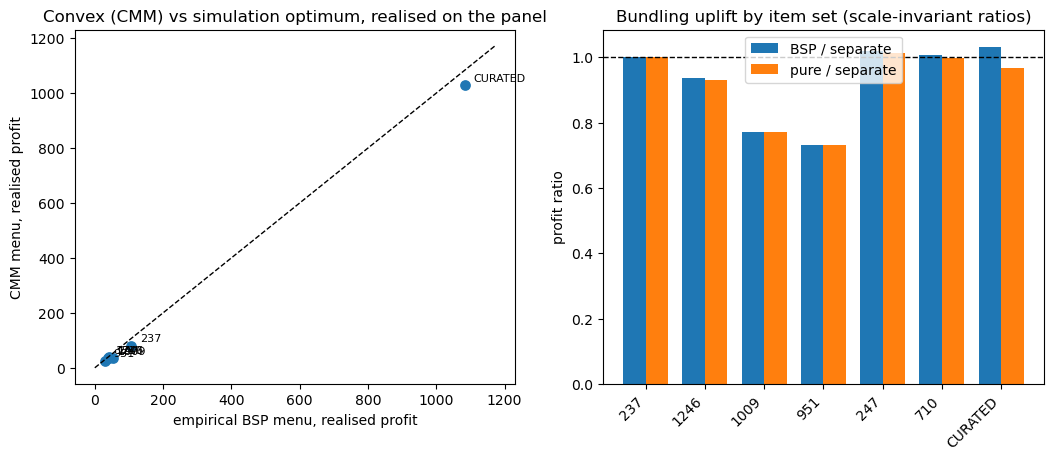

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))

lim = max(bench['de_realised'].max(), bench['cmm_realised'].max()) * 1.08
ax[0].plot([0, lim], [0, lim], 'k--', lw=1)
ax[0].scatter(bench['de_realised'], bench['cmm_realised'], s=45)
for _, r in bench.iterrows():
    ax[0].annotate(r['set'], (r['de_realised'], r['cmm_realised']),
                   textcoords='offset points', xytext=(6, 3), fontsize=8)
ax[0].set_xlabel('empirical BSP menu, realised profit')
ax[0].set_ylabel('CMM menu, realised profit')
ax[0].set_title('Convex (CMM) vs simulation optimum, realised on the panel')

xpos = np.arange(len(bench))
width = 0.38
ax[1].bar(xpos - width / 2, bench['bsp_over_separate'], width, label='BSP / separate')
ax[1].bar(xpos + width / 2, bench['pure_over_separate'], width, label='pure / separate')
ax[1].axhline(1.0, color='k', ls='--', lw=1)
ax[1].set_xticks(xpos)
ax[1].set_xticklabels(bench['set'], rotation=45, ha='right')
ax[1].set_ylabel('profit ratio')
ax[1].set_title('Bundling uplift by item set (scale-invariant ratios)')
ax[1].legend()
plt.savefig('../outputs/figures/10_benchmarks.png')
plt.show()

## Historical CMM-to-sample gap diagnostic

The CMM solver result and the best empirical sample-average solution found are different objects, and the saved values disagree substantially. This archived section examines the largest recorded gap through three diagnostics: CMM-predicted participation versus choices induced on the saved pseudo-utility panel; evaluation of the same menu on an assumed Gaussian sample with matching `(omega, Sigma)`; and the partial-sum shape in the saved panel. The exercise diagnoses the retired moment approximation and does not test the live SBA engine.

worst CMM/DE set: 710 (Sakura Bundle), cmm_real/de = 0.690
CMM q (model):    [0.0032 0.0019 0.0017 0.0024 0.0034 0.0058 0.013  0.0497 0.5284]
realized shares:  [0.     0.     0.     0.     0.     0.     0.     0.     0.4744]
outside option:   model 0.3904, realized 0.5256

CMM menu realized profit: on real W 37.01, on Gaussian W with the same moments 45.67, CMM model value 48.09
skewness of the real w_s by size: [ 9.32 12.84 15.77 17.98 17.72 17.39 16.93 16.51 15.99] (Gaussian: 0)


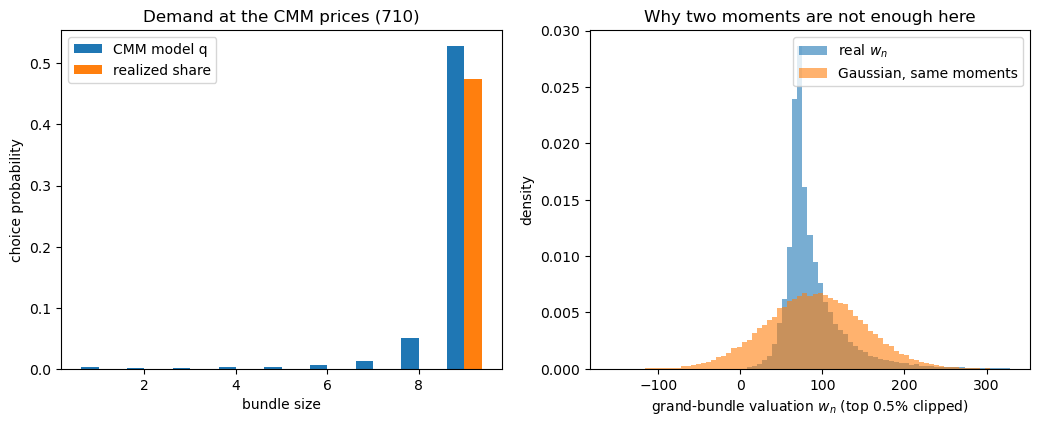

In [5]:
worst = bench.loc[bench['cmm_real_over_de'].idxmin(), 'set']
spec = sets[worst]
n = len(spec['idx']); sizes = list(range(1, n + 1))
omega, Sigma, V, info = cal.valuation_moments(P, Q, spec['idx'], sizes, calib, 'ledoit_wolf')
W = bp._top_s_sums(V, np.asarray(sizes), free_disposal=True)
conv = details[worst]['conv']

# 1. Predicted vs realized choice shares at the CMM prices.
choices = bp._user_choice_indices(W, conv['prices'], np.asarray(sizes), np.zeros(n))
shares = np.array([(choices == j).mean() for j in range(n)])
print(f'worst CMM/DE set: {worst} ({spec["name"]}), cmm_real/de = '
      f'{bench.loc[bench["set"] == worst, "cmm_real_over_de"].iloc[0]:.3f}')
print('CMM q (model):   ', np.round(conv['q'], 4))
print('realized shares: ', np.round(shares, 4))
print(f"outside option:   model {conv['q0_outside']:.4f}, realized {(choices == -1).mean():.4f}")

# 2. Gaussian control: same menu, same (omega, Sigma), Gaussian W.
rng_g = np.random.default_rng(1)
Wg = rng_g.multivariate_normal(omega, Sigma, size=n_users)
cmm_gauss = bp.evaluate_schedule(None, conv['prices'], sizes, 0.0, W=Wg)
print(f"\nCMM menu realized profit: on real W {bench.loc[bench['set'] == worst, 'cmm_realised'].iloc[0]:.2f}, "
      f"on Gaussian W with the same moments {cmm_gauss:.2f}, CMM model value {conv['profit']:.2f}")

# 3. Where the information loss is: the real partial sums are heavily skewed.
skew = ((W - W.mean(0)) ** 3).mean(0) / W.std(0) ** 3
print('skewness of the real w_s by size:', np.round(skew, 2), '(Gaussian: 0)')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
xpos = np.arange(1, n + 1)
width = 0.38
ax[0].bar(xpos - width / 2, conv['q'], width, label='CMM model q')
ax[0].bar(xpos + width / 2, shares, width, label='realized share')
ax[0].set_xlabel('bundle size'); ax[0].set_ylabel('choice probability')
ax[0].set_title(f'Demand at the CMM prices ({worst})')
ax[0].legend()

hi = float(np.percentile(W[:, -1], 99.5))
lo = float(min(0.0, Wg[:, -1].min()))
bins = np.linspace(lo, hi, 80)
ax[1].hist(W[:, -1], bins=bins, density=True, alpha=0.6, label='real $w_n$')
ax[1].hist(Wg[:, -1], bins=bins, density=True, alpha=0.6, label='Gaussian, same moments')
ax[1].set_xlabel('grand-bundle valuation $w_n$ (top 0.5% clipped)')
ax[1].set_ylabel('density')
ax[1].set_title('Why two moments are not enough here')
ax[1].legend()
plt.savefig('../outputs/figures/10_cmm_gap.png')
plt.show()

What the three saved checks show:

1. **CMM predicts more participation than the sample induces.** At the saved CMM prices for the Sakura set, the model assigns 39% to walk-away, while the archived pseudo-utility panel induces 53%. It also assigns about 8% of choice mass to sizes 1 through 8, whose induced shares round to zero at four decimals. This mechanically lowers the panel objective at the same normalized prices.

2. **The Gaussian control is closer to the CMM model value.** The identical menu on an assumed Gaussian sample with the same mean vector and covariance gives 45.7 against a model value of 48.1, while the saved Steam-derived score panel gives 37.0. This supports a limited implementation diagnostic: distributional shape beyond the first two moments contributes to the recorded gap. It is not a proof that every solver component is correct.

3. **The archived score-derived partial sums are highly right-skewed.** Their recorded skewness ranges from 9 to 18, whereas the Gaussian reference has zero population skewness. A two-moment model does not encode that shape, so matching `(omega, Sigma)` alone cannot force matching sample choices or objectives.

The appropriate archival conclusion is narrow: the saved CMM menu was sensitive to distributional features omitted by its moment summary, and the derivative-free row is only a competing best solution found. No later stage should rely on either row. The live fixed-bundle project requires new pseudo-utility scenarios, exact SBA oracles, certificates on enumerated instances, and independently benchmarked heuristics.

## Historical menu figure for the demo item set

The saved figure reuses the EA Racing Pack from notebook 09. It plots CMM and derivative-free-search size menus, the archived sample-average objective under common menu scaling, and an observed Steam-price marker. The horizontal scale combines assumed pseudo-utility units with a currency marker and is therefore incommensurate; the marker is retained for provenance, not interpretation. The plotted search maximum is numerical and uncertified.

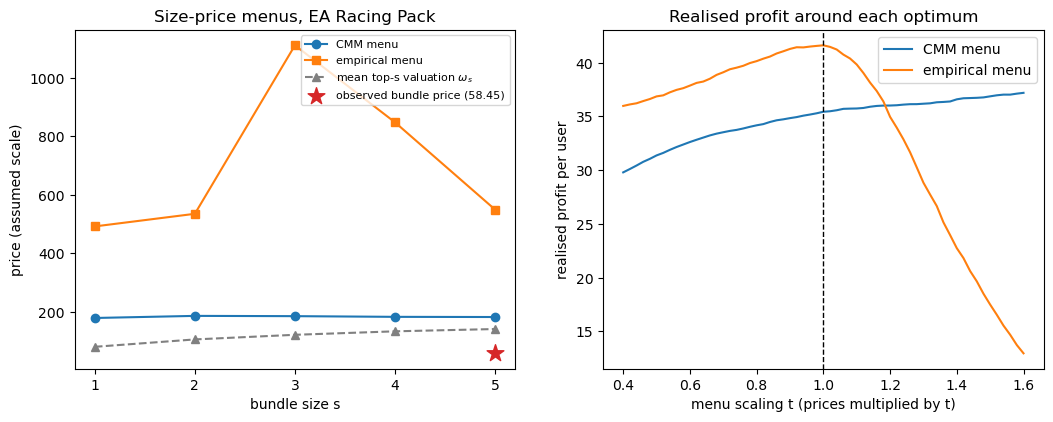

In [6]:
DEMO = '1009'
spec = sets[DEMO]
n = len(spec['idx']); sizes = np.arange(1, n + 1)
omega, Sigma, V, _ = cal.valuation_moments(P, Q, spec['idx'], list(sizes), calib, 'ledoit_wolf')
W = bp._top_s_sums(V, sizes, free_disposal=True)
conv, de = details[DEMO]['conv'], details[DEMO]['de']

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax[0].plot(sizes, conv['prices'], 'o-', label='CMM menu')
ax[0].plot(sizes, de['prices'], 's-', label='empirical menu')
ax[0].plot(sizes, omega, '^--', color='gray', label='mean top-s valuation $\\omega_s$')
ax[0].scatter([n], [spec['obs_price']], marker='*', s=160, color='tab:red', zorder=5,
              label=f"observed bundle price ({spec['obs_price']:.2f})")
ax[0].set_xticks(sizes)
ax[0].set_xlabel('bundle size s'); ax[0].set_ylabel('price (assumed scale)')
ax[0].set_title(f"Size-price menus, {spec['name']}")
ax[0].legend(fontsize=8)

ts = np.linspace(0.4, 1.6, 61)
for menu, lbl in [(conv['prices'], 'CMM menu'), (de['prices'], 'empirical menu')]:
    prof = [bp.evaluate_schedule(None, t * np.asarray(menu), list(sizes), 0.0, W=W) for t in ts]
    ax[1].plot(ts, prof, label=lbl)
ax[1].axvline(1.0, color='k', ls='--', lw=1)
ax[1].set_xlabel('menu scaling t (prices multiplied by t)')
ax[1].set_ylabel('realised profit per user')
ax[1].set_title('Realised profit around each optimum')
ax[1].legend()
plt.savefig('../outputs/figures/10_menu_demo.png')
plt.show()

## Historical scale sensitivity

Under the archived free-disposal mapping, the pseudo-utility is `max(a + b s, 0) = b * max(s + a/b, 0)`. Within this retired calculation, normalized objective ratios depend on the floor location in score units, `-a/b`; a common positive rescaling cancels only when it preserves that location and all pseudo-prices and pseudo-costs scale consistently. Both `a_shift` and `b_scale` can move the floor because `a` is re-anchored when the spread changes, so neither knob is generally cosmetic. This is a scenario sensitivity, not economic calibration. The observed Steam-price row is not an exception with a useful interpretation: it compares currency with pseudo-utility units and is incommensurate under every such transformation.

In [7]:
s_bar = cal.mean_scores(P, Q)
price_all = gf.reindex(item_ids)['standalone_price'].to_numpy(float)
hasp_all = gf.reindex(item_ids)['has_price'].fillna(False).to_numpy(bool)
own_all = gf.reindex(item_ids)['ownership_count'].to_numpy(float)
priced = hasp_all & np.isfinite(price_all) & (own_all >= 1)
idx_d = sets[DEMO]['idx']; sizes_d = list(range(1, len(idx_d) + 1))
S_d = cal.score_matrix(P, Q, idx_d)     # demo-set scores, for the floor fraction

def demo_ratios(cl, with_de=True):
    om, Sg, Vv, _ = cal.valuation_moments(P, Q, idx_d, sizes_d, cl, 'ledoit_wolf')
    Wv = bp._top_s_sums(Vv, np.asarray(sizes_d), free_disposal=True)
    se, pu = bp.separate_selling_profit(Vv), bp.pure_bundling_profit(Vv)
    bsp = np.nan
    if with_de:
        cv = bp.optimize_convex(om, Sg, 0.0, sizes_d)
        dd = bp.optimize_empirical_schedule(Vv[usamp], sizes_d, 0.0, seed=0,
                                            maxiter=200, x0=cv['prices'])
        bsp = max(pu, bp.evaluate_schedule(None, dd['prices'], sizes_d, 0.0, W=Wv),
                  bp.evaluate_schedule(None, cv['prices'], sizes_d, 0.0, W=Wv))
    obs = bp.evaluate_schedule(None, [sets[DEMO]['obs_price']], [len(idx_d)], 0.0,
                               W=Wv[:, [len(idx_d) - 1]])
    return {'floor_frac': float((cl.a + cl.b * S_d < 0).mean()),
            'BSP_over_sep': bsp / se, 'pure_over_sep': pu / se, 'obs_over_sep': obs / se}

sens_rows = []
for ash in (-5.0, 0.0, 5.0):
    cl = cal.normalize_calibration(s_bar[priced], price_all[priced], a_shift=ash)
    sens_rows.append({'knob': f'a_shift={ash:+.0f}', 'floor_in_scores': -cl.a / cl.b,
                      **demo_ratios(cl, with_de=True)})
for bs in (0.5, 2.0):
    # BSP ~= pure bundling on this bundle (see the a_shift rows), so the DE search
    # is skipped here and only the cheap ratios are reported.
    cl = cal.normalize_calibration(s_bar[priced], price_all[priced], b_scale=bs)
    sens_rows.append({'knob': f'b_scale={bs}', 'floor_in_scores': -cl.a / cl.b,
                      **demo_ratios(cl, with_de=False)})
sens = pd.DataFrame(sens_rows)
print(f'normalization sensitivity on the demo bundle ({DEMO}):')
print(sens.round(4).to_string(index=False))

# The exact invariance: joint rescaling (a, b) -> (lambda a, lambda b).
base = cal.normalize_calibration(s_bar[priced], price_all[priced])
print()
for lam in (1.0, 10.0):
    cl = cal.CalibrationResult(base.a * lam, base.b * lam, base.sigma, 'probit', True, {})
    r = demo_ratios(cl, with_de=False)
    print(f"lambda={lam:4.0f}: pure/sep={r['pure_over_sep']:.6f} (invariant)   "
          f"obs/sep={r['obs_over_sep']:.4f} (scale-dependent)")

normalization sensitivity on the demo bundle (1009):
       knob  floor_in_scores  floor_frac  BSP_over_sep  pure_over_sep  obs_over_sep
 a_shift=-5          -0.0042      0.1874        0.8816         0.8808        0.4860
 a_shift=+0          -0.0122      0.0891        0.7698         0.7698        0.5260
 a_shift=+5          -0.0203      0.0514        0.6870         0.6788        0.6761
b_scale=0.5          -0.0251      0.0391           NaN         0.7495        0.5925
b_scale=2.0          -0.0058      0.1583           NaN         0.8672        0.3646

lambda=   1: pure/sep=0.769795 (invariant)   obs/sep=0.5260 (scale-dependent)
lambda=  10: pure/sep=0.769795 (invariant)   obs/sep=0.1054 (scale-dependent)


## Archive notes

- Every numerical result in this notebook belongs to the retired arbitrary-size menu and failed assumed calibration scale. Saved `profit` labels mean normalized within-scenario objectives only; there are no monetary or actual-revenue estimates.
- The BSP row is the largest saved full-panel objective among four generated candidates. Differential evolution searched a fixed 20,000-user subsample and has no global certificate, so every such row is a best solution found.
- The recorded 69% to 97% CMM-to-search ratios and partial-sum skewness of 9 to 18 are historical diagnostics. The Gaussian control narrows one implementation discrepancy but does not certify the solver, identify demand, or isolate a causal distributional effect.
- Cross-item dependence statements are transformation- and sample-specific. The saved franchise and curated-set patterns do not establish a monotone correlation effect, a genre mechanism, or a general bundling result.
- The Australian ownership panel is a static implicit-feedback snapshot, not purchases, exposure, rejected offers, or future demand. Notebook 10 remains outside the live DAG and supplies no policy, price, candidate pool, or conclusion to later notebooks.